# =====================================================
# CASE 2
# DIRICHLET BOUNDARY CONDITION WITH SOURCE TERM
# =====================================================

Governing Equation:

∂y/∂t = k ∂²y/∂x² + S

Domain:

0 ≤ x ≤ 1

Boundary Conditions:

y(0) = 0

y(1) = 1

Source Term:

S = 1

Diffusion Coefficient:

k = 1

Initial Condition:

y(x,0) = sin(πx)

Objective:

1. Study transient behaviour
2. Study steady-state behaviour
3. Perform time-step convergence study
4. Perform mesh convergence study
5. Derive analytical solution
6. Compare analytical and numerical solutions
7. Perform error analysis

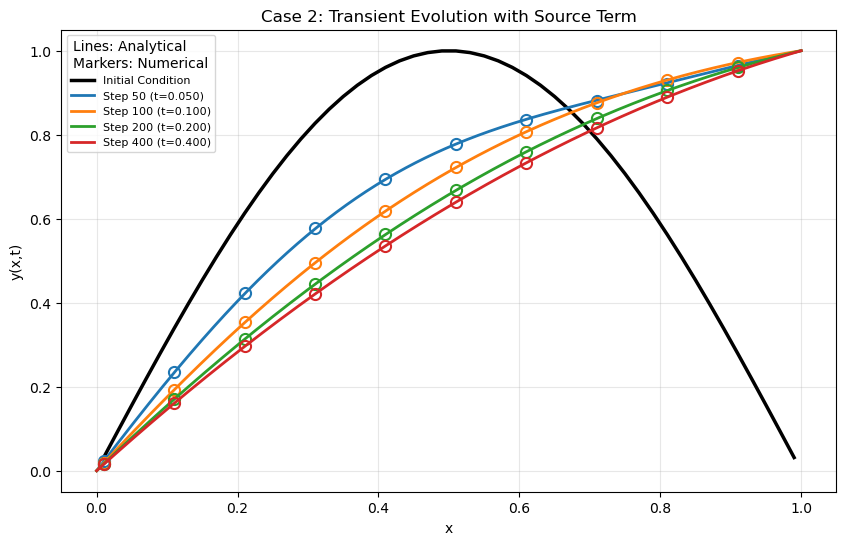

In [4]:
# =====================================================
# CASE 2 : DIRICHLET BC WITH SOURCE TERM
# TRANSIENT STUDY
# NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0

nx = 50
dx = L / nx

k = 1.0
S = 1.0

dt = 1e-3
steps = 2000

# =====================================================
# ANALYTICAL TRANSIENT SOLUTION
# =====================================================

def analytical_solution(x, t, terms=100):

    # Steady-state solution

    y_ss = -0.5 * x**2 + 1.5 * x

    # Fourier correction

    u = np.zeros_like(x)

    xx = np.linspace(0, 1, 5000)

    initial_u = (
        np.sin(np.pi * xx)
        + 0.5 * xx**2
        - 1.5 * xx
    )

    for n in range(1, terms + 1):

        integrand = (
            initial_u
            * np.sin(n * np.pi * xx)
        )

        Bn = 2 * np.trapz(integrand, xx)

        u += (
            Bn
            * np.sin(n * np.pi * x)
            * np.exp(-(n**2) * (np.pi**2) * t)
        )

    return y_ss + u

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

initial_profile = np.sin(np.pi * x)

y = CellVariable(
    name="y",
    mesh=mesh,
    value=initial_profile
)

# =====================================================
# DIRICHLET BOUNDARY CONDITIONS
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# Initial Condition

plt.plot(
    x,
    initial_profile,
    color='black',
    linewidth=2.5,
    label='Initial Condition'
)

# =====================================================
# TIMES TO COMPARE
# =====================================================

plot_steps = [50, 100, 200, 400]

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red'
]

# =====================================================
# TRANSIENT EVOLUTION
# =====================================================

for step in range(1, steps + 1):

    eq.solve(var=y, dt=dt)

    if step in plot_steps:

        idx = plot_steps.index(step)

        t_current = step * dt

        # -----------------------------------------
        # Analytical Solution (line)
        # -----------------------------------------

        x_ref = np.linspace(0, 1, 500)

        y_ana = analytical_solution(
            x_ref,
            t_current,
            terms=100
        )

        plt.plot(
            x_ref,
            y_ana,
            color=colors[idx],
            linewidth=2.0,
            label=f"Step {step} (t={t_current:.3f})"
        )

        # -----------------------------------------
        # Numerical Solution (markers)
        # -----------------------------------------

        plt.plot(
            x[::5],
            np.array(y.value)[::5],
            'o',
            color=colors[idx],
            markersize=8,
            fillstyle='none',
            markeredgewidth=1.5,
            linestyle='None'
        )

# =====================================================
# LEGEND
# =====================================================

plt.legend(
    title="Lines: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='upper left'
)

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 2: Transient Evolution with Source Term"
)

plt.xlabel("x")
plt.ylabel("y(x,t)")

plt.grid(True, alpha=0.3)

plt.savefig(
    "Case2_Transient_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

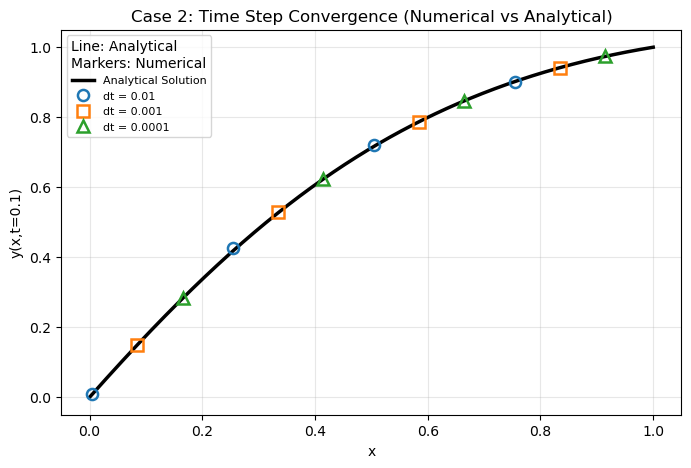

In [6]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# CASE 2 : TIME STEP CONVERGENCE STUDY
# NUMERICAL vs ANALYTICAL
# ==================================================

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
S = 1.0

dt_values = [0.01, 0.001, 0.0001]

final_time = 0.1

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

def analytical_solution(x, t, terms=100):

    y_ss = -0.5 * x**2 + 1.5 * x

    u = np.zeros_like(x)

    xx = np.linspace(0, 1, 5000)

    initial_u = (
        np.sin(np.pi * xx)
        + 0.5 * xx**2
        - 1.5 * xx
    )

    for n in range(1, terms + 1):

        integrand = initial_u * np.sin(n * np.pi * xx)

        Bn = 2 * np.trapz(integrand, xx)

        u += (
            Bn
            * np.sin(n * np.pi * x)
            * np.exp(-(n**2) * np.pi**2 * t)
        )

    return y_ss + u

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_ref = np.linspace(0, 1, 500)

analytical = analytical_solution(
    x_ref,
    final_time,
    terms=100
)

# ==================================================
# NUMERICAL SOLUTIONS
# ==================================================

solutions = []

for dt in dt_values:

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    phi.constrain(0.0, mesh.facesLeft)
    phi.constrain(1.0, mesh.facesRight)

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + S
    )

    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    solutions.append(np.array(phi.value))

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical Solution

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# --------------------------------------------------
# dt = 0.01
# --------------------------------------------------

plt.plot(
    x[::25],
    solutions[0][::25],
    'o',
    color='tab:blue',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='dt = 0.01'
)

# --------------------------------------------------
# dt = 0.001
# --------------------------------------------------

plt.plot(
    x[8::25],
    solutions[1][8::25],
    's',
    color='tab:orange',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='dt = 0.001'
)

# --------------------------------------------------
# dt = 0.0001
# --------------------------------------------------

plt.plot(
    x[16::25],
    solutions[2][16::25],
    '^',
    color='tab:green',
    markersize=9,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='dt = 0.0001'
)

# ==================================================
# PLOT SETTINGS
# ==================================================

plt.title(
    "Case 2: Time Step Convergence (Numerical vs Analytical)"
)

plt.xlabel("x")
plt.ylabel("y(x,t=0.1)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "TimeStep_Convergence_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

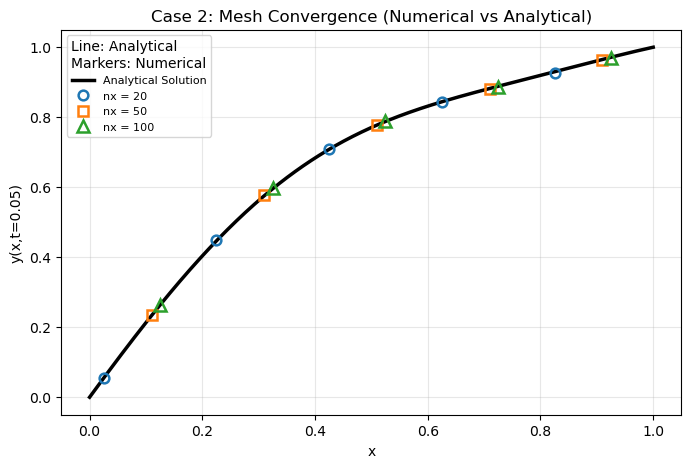

In [11]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# CASE 2 : MESH CONVERGENCE STUDY
# NUMERICAL vs ANALYTICAL
# ==================================================

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0

k = 1.0
S = 1.0

dt = 1e-3
final_time = 0.05

nx_values = [20, 50, 100]

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

def analytical_solution(x, t, terms=100):

    y_ss = -0.5 * x**2 + 1.5 * x

    u = np.zeros_like(x)

    xx = np.linspace(0, 1, 5000)

    initial_u = (
        np.sin(np.pi * xx)
        + 0.5 * xx**2
        - 1.5 * xx
    )

    for n in range(1, terms + 1):

        integrand = (
            initial_u
            * np.sin(n * np.pi * xx)
        )

        Bn = 2 * np.trapz(integrand, xx)

        u += (
            Bn
            * np.sin(n * np.pi * x)
            * np.exp(-(n**2) * np.pi**2 * t)
        )

    return y_ss + u

# ==================================================
# ANALYTICAL CURVE
# ==================================================

x_ref = np.linspace(0, 1, 500)

analytical = analytical_solution(
    x_ref,
    final_time,
    terms=100
)

# ==================================================
# NUMERICAL SOLUTIONS
# ==================================================

x_store = []
sol_store = []

for nx in nx_values:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    phi.constrain(0.0, mesh.facesLeft)
    phi.constrain(1.0, mesh.facesRight)

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + S
    )

    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    x_store.append(x)
    sol_store.append(np.array(phi.value))

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# nx = 20

plt.plot(
    x_store[0][::4],
    sol_store[0][::4],
    'o',
    color='tab:blue',
    markersize=7,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='nx = 20'
)

# nx = 50

plt.plot(
    x_store[1][5::10],
    sol_store[1][5::10],
    's',
    color='tab:orange',
    markersize=7,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='nx = 50'
)

# nx = 100

plt.plot(
    x_store[2][12::20],
    sol_store[2][12::20],
    '^',
    color='tab:green',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='nx = 100'
)

# ==================================================
# PLOT SETTINGS
# ==================================================

plt.title(
    "Case 2: Mesh Convergence (Numerical vs Analytical)"
)

plt.xlabel("x")
plt.ylabel("y(x,t=0.05)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Mesh_Convergence_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

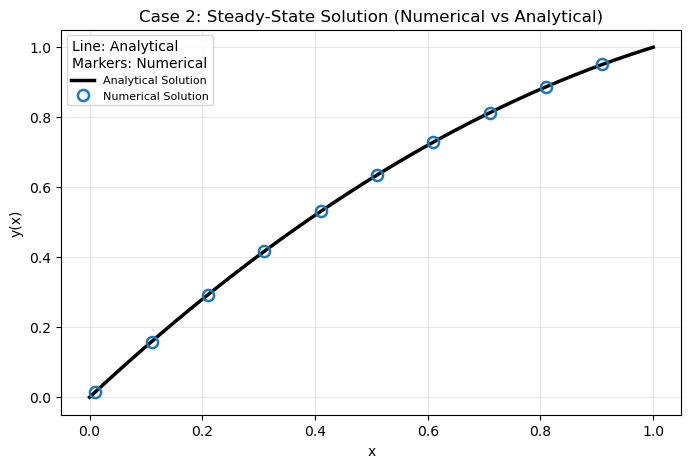

In [12]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# CASE 2 : STEADY-STATE STUDY
# NUMERICAL vs ANALYTICAL
# ==================================================

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0

nx = 50
dx = L / nx

k = 1.0
S = 1.0

dt = 1e-3
steps = 5000

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# ==================================================
# INITIAL CONDITION
# ==================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi.constrain(0.0, mesh.facesLeft)
phi.constrain(1.0, mesh.facesRight)

# ==================================================
# GOVERNING EQUATION
# ==================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

# ==================================================
# SOLVE
# ==================================================

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = np.array(phi.value)

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_ref = np.linspace(0, 1, 500)

analytical = (
    -0.5 * x_ref**2
    + 1.5 * x_ref
)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical markers

plt.plot(
    x[::5],
    numerical[::5],
    'o',
    color='tab:blue',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='Numerical Solution'
)

# ==================================================
# PLOT SETTINGS
# ==================================================

plt.title(
    "Case 2: Steady-State Solution (Numerical vs Analytical)"
)

plt.xlabel("x")
plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Steady_State_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

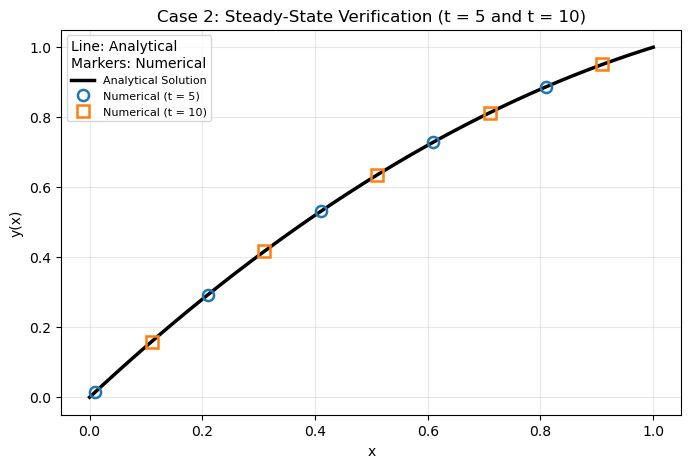


========== CASE 2 STEADY-STATE VERIFICATION ==========
Maximum Difference between t=5 and t=10 = 3.441691e-15


In [13]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# CASE 2 : STEADY-STATE VERIFICATION
# ==================================================

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 50
dx = L / nx

dt = 1e-3
S = 1.0

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# ==================================================
# SOLUTION AT t = 5
# ==================================================

phi_t5 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t5.constrain(0.0, mesh.facesLeft)
phi_t5.constrain(1.0, mesh.facesRight)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + S
)

for step in range(5000):
    eq.solve(var=phi_t5, dt=dt)

solution_t5 = np.array(phi_t5.value)

# ==================================================
# SOLUTION AT t = 10
# ==================================================

phi_t10 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t10.constrain(0.0, mesh.facesLeft)
phi_t10.constrain(1.0, mesh.facesRight)

for step in range(10000):
    eq.solve(var=phi_t10, dt=dt)

solution_t10 = np.array(phi_t10.value)

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_ref = np.linspace(0, 1, 500)

analytical = (
    -0.5 * x_ref**2
    + 1.5 * x_ref
)

# ==================================================
# COMPARISON PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical t = 5

plt.plot(
    x[::10],
    solution_t5[::10],
    'o',
    color='tab:blue',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='Numerical (t = 5)'
)

# Numerical t = 10

plt.plot(
    x[5::10],
    solution_t10[5::10],
    's',
    color='tab:orange',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='Numerical (t = 10)'
)

plt.title(
    "Case 2: Steady-State Verification (t = 5 and t = 10)"
)

plt.xlabel("x")
plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Case2_Steady_State_Verification.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==================================================
# MAXIMUM DIFFERENCE
# ==================================================

difference = np.max(
    np.abs(solution_t10 - solution_t5)
)

print("\n========== CASE 2 STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference between t=5 and t=10 = {difference:.6e}")

# =====================================================
# CASE 2 : ANALYTICAL SOLUTION
# =====================================================

Given:

∂y/∂t = k ∂²y/∂x² + S

For steady state:

∂y/∂t = 0

Therefore:

k d²y/dx² + S = 0

Using:

k = 1
S = 1

we obtain:

d²y/dx² + 1 = 0

or

d²y/dx² = -1

-----------------------------------------------------
FIRST INTEGRATION
-----------------------------------------------------

dy/dx = -x + C₁

-----------------------------------------------------
SECOND INTEGRATION
-----------------------------------------------------

y(x) = -x²/2 + C₁x + C₂

-----------------------------------------------------
APPLY BOUNDARY CONDITION 1
-----------------------------------------------------

y(0) = 0

0 = 0 + 0 + C₂

Therefore:

C₂ = 0

-----------------------------------------------------
APPLY BOUNDARY CONDITION 2
-----------------------------------------------------

y(1) = 1

1 = -1/2 + C₁

Therefore:

C₁ = 3/2

-----------------------------------------------------
FINAL ANALYTICAL SOLUTION
-----------------------------------------------------

y(x) = -x²/2 + (3/2)x

=====================================================
OBSERVATION
=====================================================

The analytical solution contains an x² term.

Therefore the steady-state solution is parabolic.

This differs from Case 1, where the analytical
solution was linear:

y(x) = x

because no source term was present.

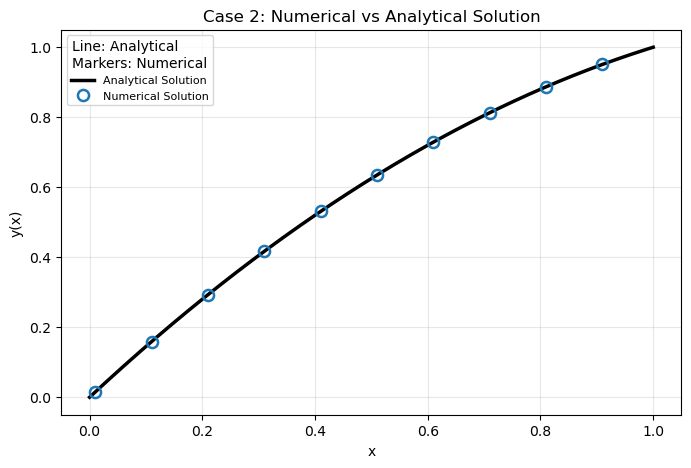

In [14]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# CASE 2 : NUMERICAL vs ANALYTICAL COMPARISON
# ==================================================

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0

nx = 50
dx = L / nx

k = 1.0
S = 1.0

dt = 1e-3
steps = 5000

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# ==================================================
# NUMERICAL SOLUTION
# ==================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi.constrain(0.0, mesh.facesLeft)
phi.constrain(1.0, mesh.facesRight)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = np.array(phi.value)

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_ref = np.linspace(0, 1, 500)

analytical = (
    -0.5 * x_ref**2
    + 1.5 * x_ref
)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical Solution

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical Solution

plt.plot(
    x[::5],
    numerical[::5],
    'o',
    color='tab:blue',
    markersize=8,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='Numerical Solution'
)

# ==================================================
# PLOT SETTINGS
# ==================================================

plt.title(
    "Case 2: Numerical vs Analytical Solution"
)

plt.xlabel("x")
plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

OBSERVATIONS

1. Numerical and analytical solutions overlap
   almost perfectly.

2. Excellent agreement is observed over the
   entire domain.

3. Numerical solution accurately reproduces
   the analytical steady-state solution.

4. FiPy implementation is validated.

5. Source-term effects are captured correctly.


========== ERROR ANALYSIS ==========
Maximum Error = 5.000000e-05
L2 Error      = 5.000000e-05


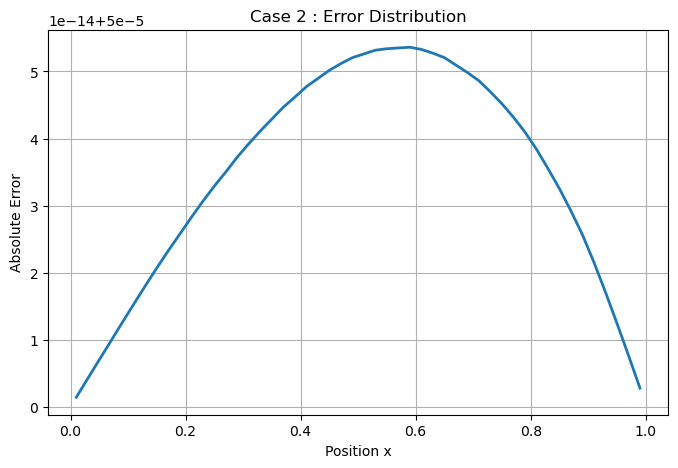

In [6]:
# =====================================================
# CASE 2 : ERROR ANALYSIS
# =====================================================

# Purpose:
#
#     Quantify the difference between
#     numerical and analytical solutions.
#
# Metrics:
#
#     1. Maximum Error
#     2. L2 Error Norm

import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# ERROR CALCULATION
# =====================================================

error = np.abs(numerical - analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

# =====================================================
# PRINT RESULTS
# =====================================================

print("\n========== ERROR ANALYSIS ==========")

print(f"Maximum Error = {max_error:.6e}")

print(f"L2 Error      = {l2_error:.6e}")

# =====================================================
# ERROR DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.title("Case 2 : Error Distribution")

plt.xlabel("Position x")
plt.ylabel("Absolute Error")

plt.grid(True)
plt.savefig("error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

OBSERVATIONS

1. Maximum error is approximately 5×10⁻⁵.

2. L2 error is approximately 5×10⁻⁵.

3. Numerical and analytical solutions show
   excellent agreement.

4. Error remains extremely small throughout
   the domain.

5. FiPy accurately reproduces the analytical
   steady-state solution.

6. Numerical implementation is successfully
   validated.